# Packed claim-history validation

This notebook checks the shared tensor history representation used by GPU Deep CFR, neural CFR+, neural FSP, and neural best responders. Claims are packed into signed `int64` words using 63 payload bits per word. Games with at most 63 claims retain the old one-tensor fast path; larger games use `[rows, words]` tensors.

The benchmark is deliberately small. History packing should be correct and cheap, but it is not expected to dominate traversal cost.

In [2]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd
import torch

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'liars_poker').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from liars_poker.algo.deep_cfr_plus import DeepCFRPlusTrainer
from liars_poker.algo.neural_cfr_plus_gpu import GPUDeepCFRPlusTraverser
from liars_poker.algo.packed_history import PackedHistory
from liars_poker.core import GameSpec

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torch:', torch.__version__)
print('device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

torch: 2.12.0+cpu
device: cpu


## Boundary and round-trip correctness

The important boundary is claim 63: claim IDs 0–62 occupy word zero, while claim 63 starts word one.

In [3]:
boundary_rows = []
for claim_count in (1, 30, 63, 64, 69, 368):
    packed = PackedHistory(claim_count, device)
    ids = torch.tensor(
        sorted({0, min(1, claim_count - 1), min(62, claim_count - 1), min(63, claim_count - 1), claim_count - 1}),
        dtype=torch.long,
        device=device,
    )
    histories = packed.append(packed.zeros(len(ids)), ids)
    decoded = packed.features(histories)
    expected = torch.zeros_like(decoded)
    expected[torch.arange(len(ids), device=device), ids] = 1.0
    torch.testing.assert_close(decoded, expected)

    selected_rows = torch.arange(len(ids) - 1, -1, -1, device=device)
    selected = packed.select(histories, selected_rows)
    torch.testing.assert_close(packed.features(selected), expected.flip(0))
    repeated = packed.repeat_interleave(histories, 3)
    torch.testing.assert_close(
        packed.features(repeated),
        expected.repeat_interleave(3, dim=0),
    )
    boundary_rows.append({
        'claims': claim_count,
        'words': packed.word_count,
        'history shape': tuple(histories.shape),
        'bytes / row': packed.word_count * 8,
    })

pd.DataFrame(boundary_rows)

,claims,words,history shape,bytes / row
0,1,1,"(1,)",8
1,30,1,"(3,)",8
2,63,1,"(3,)",8
3,64,2,"(4, 2)",16
4,69,2,"(5, 2)",16
5,368,6,"(5, 6)",48


## Exact equivalence to the legacy scalar representation

For every claim count below the boundary, packed append and decode must be bit-for-bit equivalent to the previous scalar implementation.

In [4]:
generator = torch.Generator(device=device)
generator.manual_seed(7)

for claim_count in (5, 30, 63):
    rows = 4096
    sequence_length = min(20, claim_count)
    claims = torch.randint(
        claim_count,
        (sequence_length, rows),
        generator=generator,
        device=device,
    )
    packed = PackedHistory(claim_count, device)
    packed_history = packed.zeros(rows)
    legacy_history = torch.zeros(rows, dtype=torch.long, device=device)
    legacy_masks = torch.bitwise_left_shift(
        torch.ones(claim_count, dtype=torch.long, device=device),
        torch.arange(claim_count, dtype=torch.long, device=device),
    )
    for step_claims in claims:
        packed_history = packed.append(packed_history, step_claims)
        legacy_history = torch.bitwise_or(
            legacy_history,
            legacy_masks.index_select(0, step_claims),
        )
    torch.testing.assert_close(packed_history, legacy_history)
    legacy_features = torch.bitwise_and(
        legacy_history[:, None],
        legacy_masks[None, :],
    ).ne(0).float()
    torch.testing.assert_close(packed.features(packed_history), legacy_features)

print('Scalar fast path matches the legacy representation through 63 claims.')

Scalar fast path matches the legacy representation through 63 claims.


## Production traversal smoke test above 64 claims

A small sampled-action CFR+ traversal exercises feature construction, frontier selection, packed append, reverse backup, and target generation on the 69-claim game.

In [5]:
spec_69 = GameSpec(
    ranks=6,
    suits=4,
    hand_size=4,
    claim_kinds=('RankHigh', 'Pair', 'TwoPair', 'Trips', 'FullHouse', 'Quads'),
    suit_symmetry=True,
)
trainer = DeepCFRPlusTrainer(
    spec_69,
    hidden_sizes=(64, 64),
    device=device,
    regret_buffer_capacity=1,
    strategy_buffer_capacity=1,
    batch_size=1,
    regret_train_steps=1,
    strategy_train_steps=1,
    validation_buffer_capacity=1,
    traversal_backend='gpu_native',
    traversal_batch_size=2,
    traverser_action_sample_count=4,
    device_replay=True,
    fused_optimizer=False,
)
trainer.iteration = 1
traverser = GPUDeepCFRPlusTraverser(trainer)
smoke = traverser.run_traversals(0, 2, profile=True, commit_records=False)
assert traverser.k == 69
assert traverser.history.word_count == 2
assert smoke['regret_records'] > 0 and smoke['strategy_records'] > 0
pd.DataFrame(smoke['depth_profile']).head(12)

,depth,actor,traverser,active_rows_in,traverser_claim_edges_full,traverser_claim_edges_expanded,opponent_continuations,regret_records,strategy_records,backup_s,active_rows_out,allocated_bytes,reserved_bytes,forward_s
0,0,0,0,2,138,8,0,2,0,0.000368,8,0,0,0.054677
1,1,1,0,8,0,0,7,0,8,0.000097,7,0,0,0.015140
2,2,0,0,7,145,28,0,7,0,0.000462,28,0,0,0.003686
3,3,1,0,28,0,0,24,0,28,0.000112,24,0,0,0.004040
4,4,0,0,24,102,55,0,24,0,0.000454,55,0,0,0.003907
5,5,1,0,55,0,0,33,0,55,0.000086,33,0,0,0.004106
6,6,0,0,33,58,41,0,33,0,0.000400,41,0,0,0.003262
7,7,1,0,41,0,0,18,0,41,0.000148,18,0,0,0.002711
8,8,0,0,18,23,22,0,18,0,0.000641,22,0,0,0.002893
9,9,1,0,22,0,0,8,0,22,0.000343,8,0,0,0.002889


## Microbenchmark

This measures append plus full binary-feature decode. The output allocation grows with `rows × claims`, so it intentionally includes the work the networks actually consume.

In [6]:
def synchronize():
    if device.type == 'cuda':
        torch.cuda.synchronize()

def benchmark_history(claim_count, rows, repeats=30):
    packed = PackedHistory(claim_count, device)
    histories = packed.zeros(rows)
    claim_ids = torch.randint(claim_count, (rows,), generator=generator, device=device)
    for _ in range(5):
        packed.features(packed.append(histories, claim_ids))
    synchronize()
    start = time.perf_counter()
    for _ in range(repeats):
        packed.features(packed.append(histories, claim_ids))
    synchronize()
    elapsed = time.perf_counter() - start
    return {
        'claims': claim_count,
        'words': packed.word_count,
        'rows': rows,
        'history MiB': rows * packed.word_count * 8 / 2**20,
        'feature MiB': rows * claim_count * 4 / 2**20,
        'append + decode ms': elapsed * 1000 / repeats,
        'million feature bits / s': rows * claim_count * repeats / elapsed / 1e6,
    }

benchmark_rows = 262_144 if device.type == 'cuda' else 32_768
bench = pd.DataFrame([
    benchmark_history(k, benchmark_rows)
    for k in (30, 63, 64, 69, 368)
])
bench

,claims,words,rows,history MiB,feature MiB,append + decode ms,million feature bits / s
0,30,1,32768,0.25,3.750,2.770547,354.818062
1,63,1,32768,0.25,7.875,6.162713,334.979722
2,64,2,32768,0.50,8.000,25.972023,80.746578
3,69,2,32768,0.50,8.625,28.557593,79.173058
4,368,6,32768,1.50,46.000,151.321243,79.688904


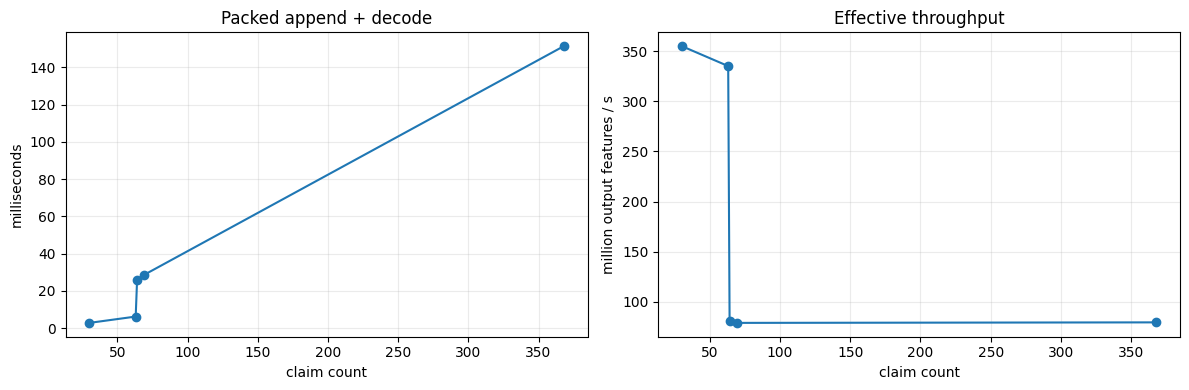

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(bench['claims'], bench['append + decode ms'], marker='o')
axes[0].set(xlabel='claim count', ylabel='milliseconds', title='Packed append + decode')
axes[0].grid(alpha=0.25)
axes[1].plot(bench['claims'], bench['million feature bits / s'], marker='o')
axes[1].set(xlabel='claim count', ylabel='million output features / s', title='Effective throughput')
axes[1].grid(alpha=0.25)
plt.tight_layout()